In [84]:
# Numerical arrays.
import numpy as np
# Combinatorics.
import itertools as it
# Plots.
import matplotlib.pyplot as plt
# Graphs.
import graphviz as gv

In [2]:
plt.rcParams['figure.figsize'] = (8.0, 8.0)

In [3]:
dtype = np.int

In [52]:
def display(M):
    """Display a matrix."""
    for r in M:
        print(" ".join(['.' if i == 0 else str(i) for i in r]))

In [49]:
def allwords(n, mod=2):
    return np.array(list(it.product(range(mod), repeat=n)))

In [54]:
def code_from_check(H, mod=2):
    words = np.array(allwords(H.shape[1], mod=mod))
    bools = ~np.any(np.matmul(H, words.T) % mod, axis=0)
    return words[bools]

In [55]:
def code_from_generator(G, mod=2):
    words = np.array(allwords(G.shape[0], mod=mod))
    code = np.matmul(words, G) % mod
    return code

<br>

## Code #1

Chapter 1, page 2

***

The matrix $A$.

In [8]:
A1 = np.array([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
], dtype=dtype)

display(A1)

. 1 1
1 . 1
1 1 .


<br>
Identity matrix $I_3$.

In [9]:
I_3 = np.eye(3, dtype=dtype)
display(I_3)

1 . .
. 1 .
. . 1


<br>
The matrix $H$.

In [10]:
H1 = np.hstack([A1, I_3])
display(H1)

. 1 1 1 . .
1 . 1 . 1 .
1 1 . . . 1


<br>
Encoding without the matrix.

In [11]:
def x4(x1, x2, x3): return (-x2 - x3) % 2
def x5(x1, x2, x3): return (-x1 - x3) % 2
def x6(x1, x2, x3): return (-x1 - x2) % 2

In [12]:
x1, x2, x3 = 0, 1, 1
x = np.array([[x1, x2, x3, x4(x1, x2, x3), x5(x1, x2, x3), x6(x1, x2, x3)]], dtype=dtype)
display(x)

. 1 1 . 1 1


<br>

All codewords.

In [13]:
for (x1, x2, x3) in allbinarywords(3):
    x = np.array([[x1, x2, x3, x4(x1, x2, x3), x5(x1, x2, x3), x6(x1, x2, x3)]], dtype=dtype)
    display(x)

. . . . . .
. . 1 1 1 .
. 1 . 1 . 1
. 1 1 . 1 1
1 . . . 1 1
1 . 1 1 . 1
1 1 . 1 1 .
1 1 1 . . .


<br>

Using the check matrix.

In [56]:
for x in allwords(len(H1[0]), 2):
    if not np.any(np.matmul(H1, x.T) % 2):
        display(np.array([x]))

. . . . . .
. . 1 1 1 .
. 1 . 1 . 1
. 1 1 . 1 1
1 . . . 1 1
1 . 1 1 . 1
1 1 . 1 1 .
1 1 1 . . .


In [15]:
display(code_from_check(H1))

. . . . . .
. . 1 1 1 .
. 1 . 1 . 1
. 1 1 . 1 1
1 . . . 1 1
1 . 1 1 . 1
1 1 . 1 1 .
1 1 1 . . .


In [16]:
display(H1)

. 1 1 1 . .
1 . 1 . 1 .
1 1 . . . 1


In [17]:
np.array(allbinarywords(H1.shape[1])).T.shape

(6, 64)

In [18]:
display(np.array(allbinarywords(H1.shape[1])))

. . . . . .
. . . . . 1
. . . . 1 .
. . . . 1 1
. . . 1 . .
. . . 1 . 1
. . . 1 1 .
. . . 1 1 1
. . 1 . . .
. . 1 . . 1
. . 1 . 1 .
. . 1 . 1 1
. . 1 1 . .
. . 1 1 . 1
. . 1 1 1 .
. . 1 1 1 1
. 1 . . . .
. 1 . . . 1
. 1 . . 1 .
. 1 . . 1 1
. 1 . 1 . .
. 1 . 1 . 1
. 1 . 1 1 .
. 1 . 1 1 1
. 1 1 . . .
. 1 1 . . 1
. 1 1 . 1 .
. 1 1 . 1 1
. 1 1 1 . .
. 1 1 1 . 1
. 1 1 1 1 .
. 1 1 1 1 1
1 . . . . .
1 . . . . 1
1 . . . 1 .
1 . . . 1 1
1 . . 1 . .
1 . . 1 . 1
1 . . 1 1 .
1 . . 1 1 1
1 . 1 . . .
1 . 1 . . 1
1 . 1 . 1 .
1 . 1 . 1 1
1 . 1 1 . .
1 . 1 1 . 1
1 . 1 1 1 .
1 . 1 1 1 1
1 1 . . . .
1 1 . . . 1
1 1 . . 1 .
1 1 . . 1 1
1 1 . 1 . .
1 1 . 1 . 1
1 1 . 1 1 .
1 1 . 1 1 1
1 1 1 . . .
1 1 1 . . 1
1 1 1 . 1 .
1 1 1 . 1 1
1 1 1 1 . .
1 1 1 1 . 1
1 1 1 1 1 .
1 1 1 1 1 1


<br>

## Code #2, page 4.

***

$A$

In [19]:
A2 = np.ones((4, 1))
display(A2)

1.0
1.0
1.0
1.0


<br>

$I_4$

In [20]:
I_4 = np.eye(4)
display(I_4)

1.0 . . .
. 1.0 . .
. . 1.0 .
. . . 1.0


<br>

$H = [A |I]$

In [21]:
H2 = np.hstack([A2, I_4])
display(H2)

1.0 1.0 . . .
1.0 . 1.0 . .
1.0 . . 1.0 .
1.0 . . . 1.0


<br>

From parity checks.

In [22]:
def x2(x1): return x1
def x3(x1): return x1
def x4(x1): return x1
def x5(x1): return x1

<br>

Code from the checks.

In [23]:
x1 = 0
x = np.array([[x1, x2(x1), x3(x1), x4(x1), x5(x1)]], dtype=dtype)
display(x)
x1 = 1
x = np.array([[x1, x2(x1), x3(x1), x4(x1), x5(x1)]], dtype=dtype)
display(x)

. . . . .
1 1 1 1 1


<br>

Code from check matrix.

In [24]:
display(code_from_check(H2))

. . . . .
1 1 1 1 1


<br>

## Code #3, page 4

***

In [25]:
H3 = np.array([[1, 1, 1, 1]], dtype=dtype)

In [26]:
display(code_from_check(H3))

. . . .
. . 1 1
. 1 . 1
. 1 1 .
1 . . 1
1 . 1 .
1 1 . .
1 1 1 1


<br>

## Problem (1): Code #4, page 4

***

In [27]:
H4a = np.array([[1, 0, 1, 0], [1, 1, 0, 1]], dtype=dtype)

In [28]:
display(code_from_check(H4a))

. . . .
. 1 . 1
1 . 1 1
1 1 1 .


In [29]:
H4b = np.array([[0, 1, 1, 1], [1, 1, 0, 1]], dtype=dtype)

In [30]:
display(code_from_check(H4b))

. . . .
. 1 . 1
1 . 1 1
1 1 1 .


<br>

## Problem (2): Code #5, page 4

***

In [31]:
H5 = np.array([[0, 1, 1, 1, 1, 0, 0], [1, 0, 1, 1, 0, 1, 0], [1, 1, 0, 1, 0, 0, 1]], dtype=dtype)

In [32]:
display(code_from_check(H5))

. . . . . . .
. . . 1 1 1 1
. . 1 . 1 1 .
. . 1 1 . . 1
. 1 . . 1 . 1
. 1 . 1 . 1 .
. 1 1 . . 1 1
. 1 1 1 1 . .
1 . . . . 1 1
1 . . 1 1 . .
1 . 1 . 1 . 1
1 . 1 1 . 1 .
1 1 . . 1 1 .
1 1 . 1 . . 1
1 1 1 . . . .
1 1 1 1 1 1 1


<br>

## Problem (3): page 4

***

$p > \frac{1}{2}$

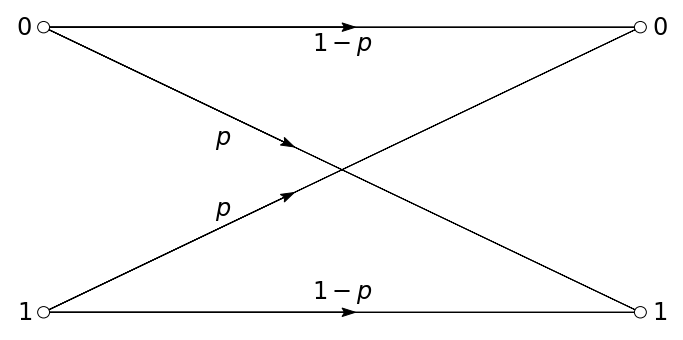

In [33]:
fig, ax = plt.subplots(figsize=(12,6))

ax.arrow(0,  0, 20,   0)
ax.arrow(0,  0, 20,  10)
ax.arrow(0, 10, 20, -10)
ax.arrow(0, 10, 20,   0)

ax.arrow(0,  0, 10,   0, head_width=0.3, fc='k', overhang=0.2)
ax.arrow(0,  0,  8,   4, head_width=0.3, fc='k', overhang=0.2)
ax.arrow(0, 10,  8,  -4, head_width=0.3, fc='k', overhang=0.2)
ax.arrow(0, 10, 10,   0, head_width=0.3, fc='k', overhang=0.2)

ax.text(10, 0.5, "$1-p$", fontsize=24, horizontalalignment='center')
ax.text(10, 9.2, "$1-p$", fontsize=24, horizontalalignment='center')
ax.text( 6, 3.4, "$p$",   fontsize=24, horizontalalignment='center')
ax.text( 6, 5.9, "$p$",   fontsize=24, horizontalalignment='center')

ax.add_patch(plt.Circle((0,   0), 0.2, color='k', fc='w'))
ax.add_patch(plt.Circle((0,  10), 0.2, color='k', fc='w'))
ax.add_patch(plt.Circle((20,  0), 0.2, color='k', fc='w'))
ax.add_patch(plt.Circle((20, 10), 0.2, color='k', fc='w'))

ax.text(-0.4,  0, "$1$", fontsize=24, horizontalalignment='right', verticalalignment='center')
ax.text(-0.4, 10, "$0$", fontsize=24, horizontalalignment='right', verticalalignment='center')
ax.text(20.4,  0, "$1$", fontsize=24, horizontalalignment='left',  verticalalignment='center')
ax.text(20.4, 10, "$0$", fontsize=24, horizontalalignment='left',  verticalalignment='center')

ax.axis('off');

<br>

#### Generator Matrix, Code 1, page 6

***

In [34]:
G1 = np.hstack([I_3, A1])
display(G1)

1 . . . 1 1
. 1 . 1 . 1
. . 1 1 1 .


In [35]:
G1_codewords = code_from_generator(G1)
display(G1_codewords)

. . . . . .
. . 1 1 1 .
. 1 . 1 . 1
. 1 1 . 1 1
1 . . . 1 1
1 . 1 1 . 1
1 1 . 1 1 .
1 1 1 . . .


<br>

#### Two generator matrices, Code 4, page 6

***

In [36]:
G4a = np.array([[1, 1, 1, 0], [0, 1, 0, 1]], dtype=dtype)
display(G4a)

1 1 1 .
. 1 . 1


In [37]:
G4b = np.array([[1, 0, 1, 1], [0, 1, 0, 1]], dtype=dtype)
display(G4b)

1 . 1 1
. 1 . 1


In [38]:
display(code_from_generator(G4a))

. . . .
. 1 . 1
1 1 1 .
1 . 1 1


In [39]:
display(code_from_generator(G4b))

. . . .
. 1 . 1
1 . 1 1
1 1 1 .


<br>

## Code #6

***

In [40]:
A6 = np.array([[1, 1], [1, 2]], dtype=dtype)
display(A6)

1 1
1 2


In [41]:
I_2 = np.eye(2, dtype=dtype)
display(I_2)

1 .
. 1


In [42]:
H6 = np.hstack([A6, I_2])
display(H6)

1 1 1 .
1 2 . 1


In [43]:
G6 = np.hstack([I_2, (-A6 % 3).T])
display(G6)

1 . 2 2
. 1 2 1


In [58]:
display(code_from_generator(G6, 3))

. . . .
. 1 2 1
. 2 1 2
1 . 2 2
1 1 1 .
1 2 . 1
2 . 1 1
2 1 . 2
2 2 2 .


<br>

## Problem 4, page 7

***

$G_{1 \times n} = [ 1 1 1 \ldots 1 ]$


$H_{n-1 \times n} = \left[ \begin{matrix}
-1 & 1 & 0 & 0 & \ldots & 0 \\
-1 & 0 & 1 & 0 & \ldots & 0 \\
-1 & 0 & 0 & 1 & \ldots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
-1 & 0 & 0 & 0 & \ldots & 1 \\
\end{matrix} \right]$

<br>

#### Problem 5, page 7

***

$G_{n-1 \times n} = \left[ \begin{matrix}
-1 & 1 & 0 & 0 & \ldots & 0 \\
-1 & 0 & 1 & 0 & \ldots & 0 \\
-1 & 0 & 0 & 1 & \ldots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
-1 & 0 & 0 & 0 & \ldots & 1 \\
\end{matrix} \right]$

$H_{1 \times n} = [ 1 1 1 \ldots 1 ]$


<br>

#### Problem 6, page 8

***

$\mathcal{C}$ is $\mathbb{F}^n$.

<br>

#### Hamming distance, page 8

***

In [109]:
def hamming(x, y=None):
    if y is None:
        return sum([1 if x[i] != 0 else 0 for i in range(len(x))])
    else:
        return sum([1 if x[i] != y[i] else 0 for i in range(len(x))])        

In [110]:
hamming([0,1,1,1], [1,1,1,0])

2

In [111]:
hamming([1,1,1,0,0,0])

3

In [112]:
x = np.array([0,1,1,1])
y = np.array([1,1,1,0])
hamming(x, y), hamming(x - y)

(2, 2)

<br>

#### Intersection, page 9

***

In [113]:
def intersection(x, y):
    return x * y

In [114]:
x = np.array([1,1,0,0,1])
y = np.array([1,0,1,1,1])
intersection(x, y)

array([1, 0, 0, 0, 1])

In [115]:
hamming((x + y) % 2), hamming(x) + hamming(y) - 2 * hamming(x * y)

(3, 3)

<br>

### Errors, page 9

***

In [116]:
def prob(e, p):
    w = hamming(e)
    n = len(e)
    val = (p ** w) * ((1 - p) ** (n - w))
    return val

In [117]:
prob([0,0,0,0,0], 1/10)

0.5904900000000001

In [118]:
prob([0,1,0,0,0], 1/10)

0.06561

In [119]:
prob([1,0,0,1,0], 1/10)

0.007290000000000002

In [120]:
sorted([(e, prob(e, 0.2)) for e in allwords(3, 2)], key=lambda x: -x[1])

[(array([0, 0, 0]), 0.5120000000000001),
 (array([0, 0, 1]), 0.12800000000000003),
 (array([0, 1, 0]), 0.12800000000000003),
 (array([1, 0, 0]), 0.12800000000000003),
 (array([0, 1, 1]), 0.03200000000000001),
 (array([1, 0, 1]), 0.03200000000000001),
 (array([1, 1, 0]), 0.03200000000000001),
 (array([1, 1, 1]), 0.008000000000000002)]

<br>

#### Brute force decoding, page 9

***

In [121]:
def brute_decode(C, y):
    c = C[0]
    for d in C:
        if hamming(d, y) < hamming(c, y):
            c = d
    return c

In [122]:
brute_decode(code_from_generator(G4b), [0, 1, 0, 0])

array([0, 0, 0, 0])

In [123]:
code_from_generator(G4b)

array([[0, 0, 0, 0],
       [0, 1, 0, 1],
       [1, 0, 1, 1],
       [1, 1, 1, 0]])

<br>

#### Minimum distance, page 9

***

In [127]:
def min_distance(C):
    wt = len(C[0])
    for c in C:
        if hamming(c) == 0:
            continue
        else:
            if hamming(c) < wt:
                wt = hamming(c)
    return wt

In [134]:
display(code_from_generator(G1))
min_distance(code_from_generator(G1))

. . . . . .
. . 1 1 1 .
. 1 . 1 . 1
. 1 1 . 1 1
1 . . . 1 1
1 . 1 1 . 1
1 1 . 1 1 .
1 1 1 . . .


3